In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score
import warnings
warnings.filterwarnings('ignore')
# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# 数据集类
class ISICDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        # 获取所有图像文件（支持.jpg和.png）
        all_files = os.listdir(image_dir)
        self.images = [f for f in all_files if f.lower().endswith(('.jpg', '.png'))]
        
        # 获取所有mask文件
        mask_files = []
        if os.path.exists(mask_dir):
            for item in os.listdir(mask_dir):
                item_path = os.path.join(mask_dir, item)
                if os.path.isdir(item_path):
                    # 如果是文件夹，获取文件夹内的png文件
                    mask_files.extend([os.path.join(item, f) for f in os.listdir(item_path) 
                                     if f.lower().endswith('.png')])
                elif item.lower().endswith('.png'):
                    # 如果是png文件
                    mask_files.append(item)
        
        self.mask_files = mask_files
        
        # 过滤出有对应mask的图像
        valid_images = []
        for img_file in self.images:
            img_base = os.path.splitext(img_file)[0]
            # 查找对应的mask文件
            for mask_file in self.mask_files:
                mask_base = os.path.splitext(os.path.basename(mask_file))[0]
                if img_base == mask_base or img_base in mask_base or mask_base in img_base:
                    valid_images.append((img_file, mask_file))
                    break
        
        self.valid_pairs = valid_images
        print(f"Found {len(self.valid_pairs)} valid image-mask pairs in {image_dir}")
        
    def __len__(self):
        return len(self.valid_pairs)
    
    def __getitem__(self, idx):
        img_file, mask_file = self.valid_pairs[idx]
        img_path = os.path.join(self.image_dir, img_file)
        mask_path = os.path.join(self.mask_dir, mask_file)
        
        # 加载图像和mask
        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')
        
        # 调整大小
        image = image.resize((128, 128))
        mask = mask.resize((128, 128))
        
        # 转换为tensor
        image = transforms.ToTensor()(image)
        mask = transforms.ToTensor()(mask)
        
        # 二值化mask（处理不同的编码方式）
        mask = (mask > 0.5).float()
        
        return image, mask

In [3]:
# UNet模型定义
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        
        # 编码器
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        
        # 池化
        self.pool = nn.MaxPool2d(2)
        
        # 瓶颈层
        self.bottleneck = DoubleConv(512, 1024)
        
        # 解码器
        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        
        # 输出层
        self.out = nn.Conv2d(64, out_channels, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # 编码器
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))
        
        # 瓶颈层
        bottleneck = self.bottleneck(self.pool(enc4))
        
        # 解码器
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.dec4(dec4)
        
        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.dec3(dec3)
        
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.dec2(dec2)
        
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.dec1(dec1)
        
        return self.sigmoid(self.out(dec1))

In [4]:
# Dice Loss
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, inputs, targets):
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)
        
        return 1 - dice

# 计算指标
def calculate_metrics(pred, target):
    pred = pred.cpu().numpy()
    target = target.cpu().numpy()
    
    pred_binary = (pred > 0.5).astype(int)
    target_binary = (target > 0.5).astype(int)
    
    # 计算IoU (Jaccard Index)
    intersection = np.sum(pred_binary * target_binary)
    union = np.sum(pred_binary) + np.sum(target_binary) - intersection
    iou = intersection / (union + 1e-8)
    
    # 计算Dice系数
    dice = (2. * intersection) / (np.sum(pred_binary) + np.sum(target_binary) + 1e-8)
    
    return iou, dice

# 训练函数
def train_model(model, train_loader, val_loader, num_epochs=20, learning_rate=0.001):
    criterion = DiceLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        # 训练阶段
        model.train()
        train_loss = 0.0
        
        for i, (images, masks) in enumerate(train_loader):
            images = images.to(device)
            masks = masks.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            if i % 10 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
        
        # 验证阶段
        model.eval()
        val_loss = 0.0
        val_iou = 0.0
        val_dice = 0.0
        
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()
                
                # 计算指标
                iou, dice = calculate_metrics(outputs, masks)
                val_iou += iou
                val_dice += dice
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        avg_val_iou = val_iou / len(val_loader)
        avg_val_dice = val_dice / len(val_loader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        # 学习率调整
        scheduler.step(avg_val_loss)
        
        print(f'Epoch [{epoch+1}/{num_epochs}]:')
        print(f'  Train Loss: {avg_train_loss:.4f}')
        print(f'  Val Loss: {avg_val_loss:.4f}')
        print(f'  Val IoU: {avg_val_iou:.4f}')
        print(f'  Val Dice: {avg_val_dice:.4f}')
        print(f'  Learning Rate: {optimizer.param_groups[0]["lr"]:.6f}')
        print('-' * 50)
        
        # 保存最佳模型
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f'  New best model saved with val loss: {best_val_loss:.4f}')
    
    return train_losses, val_losses

# 测试函数
def test_model(model, test_loader):
    model.eval()
    test_iou = 0.0
    test_dice = 0.0
    
    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            
            # 计算指标
            iou, dice = calculate_metrics(outputs, masks)
            test_iou += iou
            test_dice += dice
    
    avg_test_iou = test_iou / len(test_loader)
    avg_test_dice = test_dice / len(test_loader)
    
    print(f'Test Results:')
    print(f'  Test IoU: {avg_test_iou:.4f}')
    print(f'  Test Dice: {avg_test_dice:.4f}')
    
    return avg_test_iou, avg_test_dice

# 可视化结果
def visualize_results(model, test_loader, num_samples=5):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    with torch.no_grad():
        for i, (images, masks) in enumerate(test_loader):
            if i >= num_samples:
                break
            
            images = images.to(device)
            outputs = model(images)
            
            # 取第一个样本
            image = images[0].cpu().numpy().transpose(1, 2, 0)
            mask = masks[0].cpu().numpy().squeeze()
            pred = outputs[0].cpu().numpy().squeeze()
            
            if num_samples == 1:
                axes[0].imshow(image)
                axes[0].set_title('Original Image')
                axes[0].axis('off')
                
                axes[1].imshow(mask, cmap='gray')
                axes[1].set_title('Ground Truth')
                axes[1].axis('off')
                
                axes[2].imshow(pred, cmap='gray')
                axes[2].set_title('Prediction')
                axes[2].axis('off')
            else:
                axes[i, 0].imshow(image)
                axes[i, 0].set_title('Original Image')
                axes[i, 0].axis('off')
                
                axes[i, 1].imshow(mask, cmap='gray')
                axes[i, 1].set_title('Ground Truth')
                axes[i, 1].axis('off')
                
                axes[i, 2].imshow(pred, cmap='gray')
                axes[i, 2].set_title('Prediction')
                axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()


Checking data paths...
✓ Train images: E:\ISIC\data\train_data\ISIC-2017_Training_Data
✓ Train masks: E:\ISIC\data\train_GroundTruth
✓ Val images: E:\ISIC\data\Validation_data\ISIC-2017_Validation_Data
✓ Val masks: E:\ISIC\data\Validation_GroundTruth
✓ Test images: E:\ISIC\data\test_data\ISIC-2017_Test_v2_Data
✓ Test masks: E:\ISIC\data\test_GroundTruth

Creating datasets...
Found 2000 valid image-mask pairs in E:\ISIC\data\train_data\ISIC-2017_Training_Data
Found 150 valid image-mask pairs in E:\ISIC\data\Validation_data\ISIC-2017_Validation_Data
Found 600 valid image-mask pairs in E:\ISIC\data\test_data\ISIC-2017_Test_v2_Data
Train samples: 2000
Validation samples: 150
Test samples: 600

Starting training...
Epoch [1/5], Step [1/500], Loss: 0.4811
Epoch [1/5], Step [11/500], Loss: 0.6029
Epoch [1/5], Step [21/500], Loss: 0.2607
Epoch [1/5], Step [31/500], Loss: 0.1728
Epoch [1/5], Step [41/500], Loss: 0.7109
Epoch [1/5], Step [51/500], Loss: 0.3582
Epoch [1/5], Step [61/500], Loss: 0

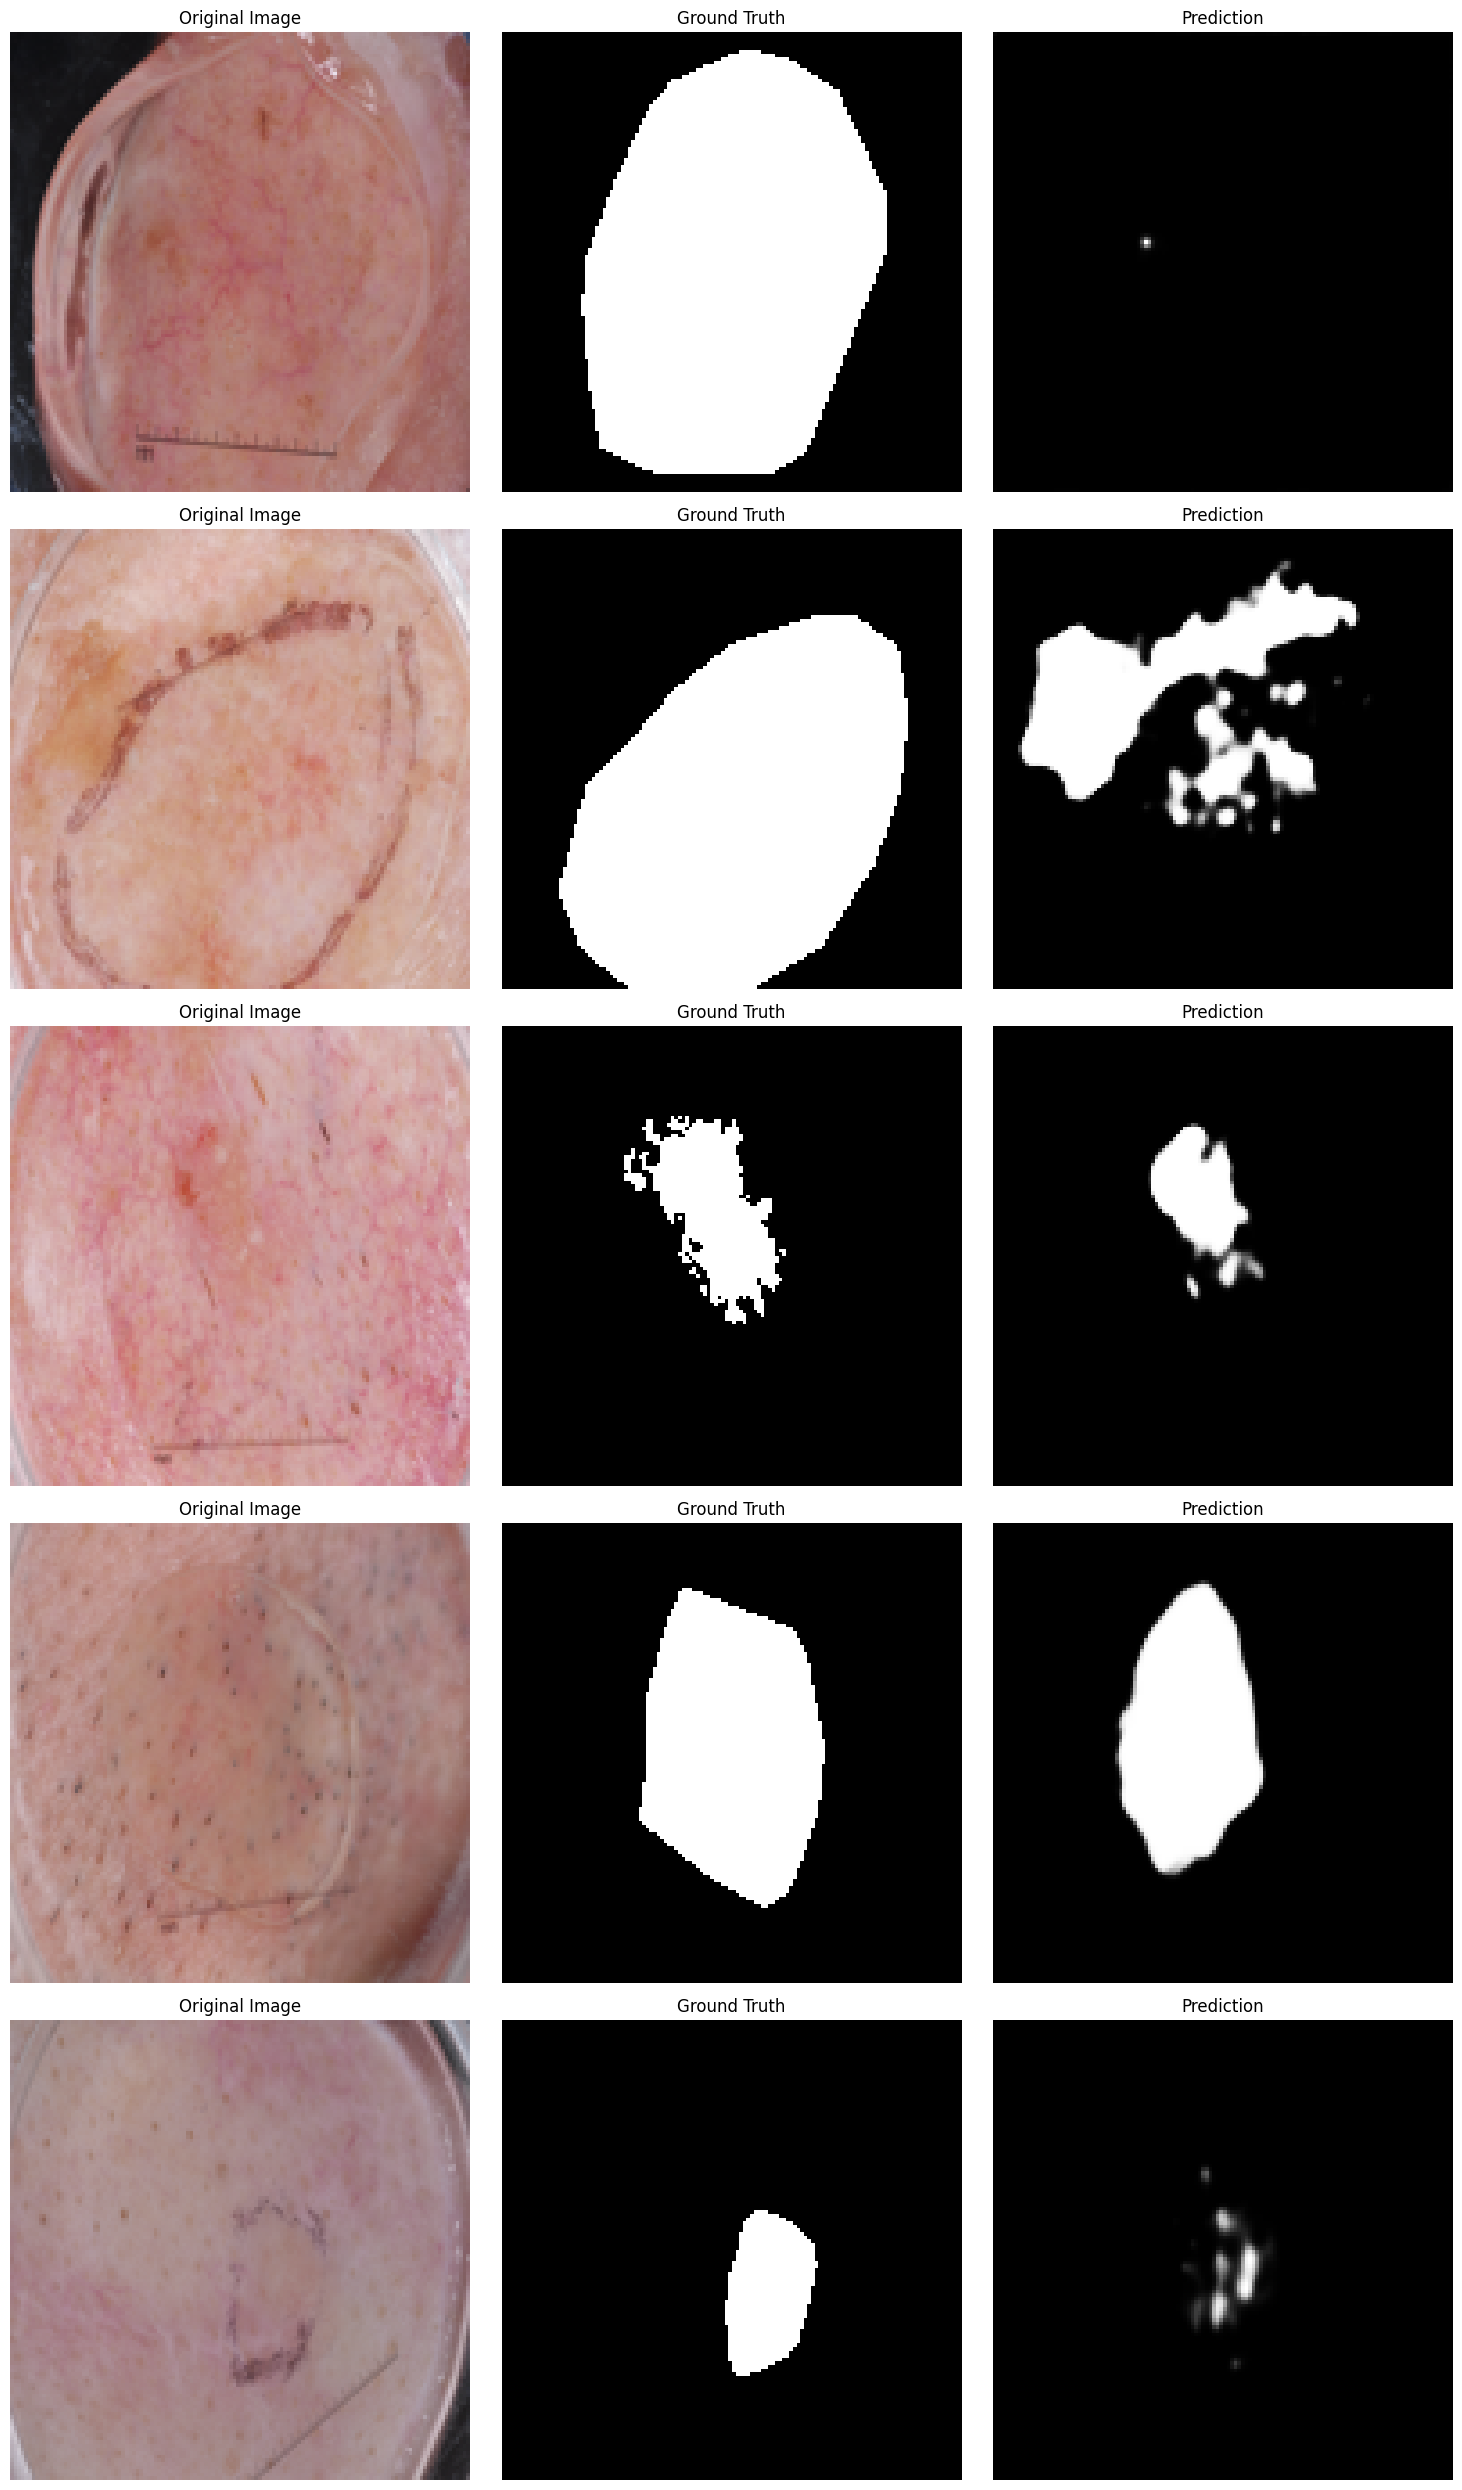

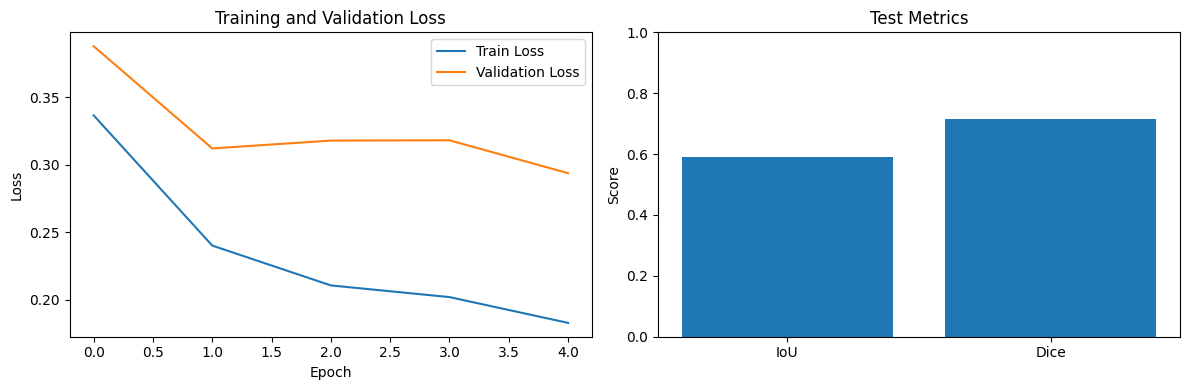


Final Results:
Test IoU: 0.5904
Test Dice: 0.7160


In [5]:
# 主函数
def main():
    # 数据路径（根据您的实际文件夹结构）
    base_path = r'E:\ISIC\data'
    
    # 训练数据
    train_image_dir = os.path.join(base_path, 'train_data', 'ISIC-2017_Training_Data')
    train_mask_dir = os.path.join(base_path, 'train_GroundTruth')
    
    # 验证数据
    val_image_dir = os.path.join(base_path, 'Validation_data', 'ISIC-2017_Validation_Data')
    val_mask_dir = os.path.join(base_path, 'Validation_GroundTruth')
    
    # 测试数据
    test_image_dir = os.path.join(base_path, 'test_data', 'ISIC-2017_Test_v2_Data')
    test_mask_dir = os.path.join(base_path, 'test_GroundTruth')
    
    # 检查数据路径
    print("Checking data paths...")
    for name, path in [('Train images', train_image_dir), ('Train masks', train_mask_dir),
                       ('Val images', val_image_dir), ('Val masks', val_mask_dir),
                       ('Test images', test_image_dir), ('Test masks', test_mask_dir)]:
        if os.path.exists(path):
            print(f"✓ {name}: {path}")
        else:
            print(f"✗ {name}: {path} (NOT FOUND)")
    
    # 创建数据集
    print("\nCreating datasets...")
    train_dataset = ISICDataset(train_image_dir, train_mask_dir)
    val_dataset = ISICDataset(val_image_dir, val_mask_dir)
    test_dataset = ISICDataset(test_image_dir, test_mask_dir)
    
    # 如果某个数据集为空，尝试用其他数据集代替
    if len(train_dataset) == 0:
        print("Warning: No training data found. Using validation data for training.")
        train_dataset = val_dataset
    
    if len(val_dataset) == 0:
        print("Warning: No validation data found. Using training data for validation.")
        val_dataset = train_dataset
    
    if len(test_dataset) == 0:
        print("Warning: No test data found. Using validation data for testing.")
        test_dataset = val_dataset
    
    print(f'Train samples: {len(train_dataset)}')
    print(f'Validation samples: {len(val_dataset)}')
    print(f'Test samples: {len(test_dataset)}')
    
    # 创建数据加载器
    batch_size = 4  # 减小batch size以适应不同大小的数据集
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # 创建模型
    model = UNet(in_channels=3, out_channels=1).to(device)
    
    # 训练模型
    print('\nStarting training...')
    train_losses, val_losses = train_model(model, train_loader, val_loader, num_epochs=5)
    
    # 加载最佳模型
    if os.path.exists('best_model.pth'):
        model.load_state_dict(torch.load('best_model.pth'))
        print('Best model loaded successfully.')
    
    # 测试模型
    print('\nTesting model...')
    test_iou, test_dice = test_model(model, test_loader)
    
    # 可视化结果
    print('\nVisualizing results...')
    visualize_results(model, test_loader)
    
    # 绘制训练曲线
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.bar(['IoU', 'Dice'], [test_iou, test_dice])
    plt.title('Test Metrics')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    print(f'\nFinal Results:')
    print(f'Test IoU: {test_iou:.4f}')
    print(f'Test Dice: {test_dice:.4f}')

if __name__ == "__main__":
    main()

In [6]:
import os

# 查看当前工作目录
print("当前工作目录:", os.getcwd())

# 检查模型文件是否存在
if os.path.exists('best_model.pth'):
    full_path = os.path.abspath('best_model.pth')
    print(f"✓ 模型文件位置: {full_path}")
    print(f"文件大小: {os.path.getsize('best_model.pth') / 1024 / 1024:.2f} MB")
else:
    print("✗ best_model.pth 文件未找到")
    
# 列出当前目录所有文件
print("\n当前目录文件列表:")
for f in os.listdir('.'):
    if f.endswith('.pth') or f.endswith('.pt'):
        print(f"  📁 {f}")

当前工作目录: C:\Users\86131
✓ 模型文件位置: C:\Users\86131\best_model.pth
文件大小: 118.51 MB

当前目录文件列表:
  📁 best_model.pth
  📁 linear_regression_pytorch.pth
